In [48]:
import pandas as pd

filename = "lc_cat.dat"

headers = ['objnum', 'ra', 'dec', 'objtype', 'glat', 'glong', 'dist', 'blendalert',
    'period', 'amplitude', 'mjd0', 'voff', 'avmagq', 'itempl', 'nfit',
    'chi2', 'vcalib', 'vext', 'absmag', 'a0four', 'a1four', 'a2four',
    'a3four', 'a4four', 'a5four', 'a6four', 'phi21four', 'phi31four',
    'phi41four', 'phi51four', 'phi61four', 'fourlcfix', 'dmaxfour', 'p_phi', 'fehlbob', 'fehcbob']

star_ids = []
ra_list = []
period_list=[]
dec_list = []
time_list = []
flux_list = []
flux_err_list = []

with open(filename, 'r') as f:
    star_counter = 0
    while True:
        line = f.readline()
        if not line:
            break
            
        meta_values = line.strip().split()
        if len(meta_values) != len(headers):
            print(f"Warning: unexpected metadata length at star {star_counter}")
            continue

        meta_dict = dict(zip(headers, meta_values))
        ra = float(meta_dict['ra'])
        dec = float(meta_dict['dec'])
        period = float(meta_dict['period'])
        star_counter += 1
        star_id = star_counter

        npoints_line = f.readline()
        if not npoints_line:
            break
        npoints = int(npoints_line.strip())

        for _ in range(npoints):
            lc_line = f.readline()
            if not lc_line:
                break
            t, flux, ferr = map(float, lc_line.strip().split())
            star_ids.append(star_id)
            ra_list.append(ra)
            dec_list.append(dec)
            time_list.append(t)
            period_list.append(period)
            flux_list.append(flux)
            flux_err_list.append(ferr)

lc_df1 = pd.DataFrame({
    'star_id': star_ids,
    'ra': ra_list,
    'dec': dec_list,
    'period': period_list,
    'time': time_list,
    'flux': flux_list,
    'flux_err': flux_err_list
})

print(lc_df1.head())

   star_id       ra      dec    period          time       flux  flux_err
0        1  0.01303 -2.43007  0.493024  55406.391382  16.985323  0.033540
1        1  0.01303 -2.43007  0.493024  55406.392782  16.918287  0.030068
2        1  0.01303 -2.43007  0.493024  55409.423397  16.986592  0.069537
3        1  0.01303 -2.43007  0.493024  55409.424786  16.990150  0.040353
4        1  0.01303 -2.43007  0.493024  55426.316622  16.360303  0.033540


In [49]:
counts = lc_df1.groupby("star_id")["time"].count()

good_ids = counts[counts > 50].index

lc_df1 = lc_df1[lc_df1["star_id"].isin(good_ids)].reset_index(drop=True)

print(f"Kept {len(good_ids)} stars with > 50 points.")
print(lc_df1.head())

Kept 20420 stars with > 50 points.
   star_id        ra        dec    period          time       flux  flux_err
0        2  0.027391 -15.498159  0.525935  55446.088528  20.356672  0.101054
1        2  0.027391 -15.498159  0.525935  55446.334198  19.697553  0.087205
2        2  0.027391 -15.498159  0.525935  55473.039978  20.387863  0.134113
3        2  0.027391 -15.498159  0.525935  55824.135278  20.277584  0.131658
4        2  0.027391 -15.498159  0.525935  55824.210653  20.211716  0.135171


In [50]:
import pandas as pd
import numpy as np

counts = lc_df1.groupby("star_id")["time"].count()

med_err = lc_df1.groupby("star_id")["flux_err"].median()

amplitude = lc_df1.groupby("star_id")["flux"].apply(lambda x: np.max(x) - np.min(x))

qc = pd.DataFrame({
    "n_points": counts,
    "median_err": med_err,
    "amplitude": amplitude})

good_ids = qc[(qc["n_points"] > 50) & (qc["median_err"] < 0.032) & (qc["amplitude"] > 0.4)].index

lc_df_good = lc_df1[lc_df1["star_id"].isin(good_ids)].reset_index(drop=True)

print(f"Kept {len(good_ids)} stars with >50 points, median err <0.05, amplitude >0.2")
print(f"Total light-curve rows: {len(lc_df_good)}")

Kept 839 stars with >50 points, median err <0.05, amplitude >0.2
Total light-curve rows: 169071


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

counts = lc_df1.groupby("star_id")["time"].count()
med_err = lc_df1.groupby("star_id")["flux_err"].median()
amplitude = lc_df1.groupby("star_id")["flux"].apply(lambda x: np.max(x) - np.min(x))
periods = lc_df1.groupby("star_id")["period"].first()

qc = pd.DataFrame({
    "n_points": counts,
    "median_err": med_err,
    "amplitude": amplitude,
    "period": periods})

good_ids = qc[
    (qc["n_points"] > 100) &
    (qc["median_err"] < 0.033) &
    (qc["amplitude"] > 0.4) & (qc["amplitude"] < 1.5) &
    (qc["period"].between(0.44, 0.89))].index

lc_df_good = lc_df1[lc_df1["star_id"].isin(good_ids)].reset_index(drop=True)

print(f"Kept {len(good_ids)} stars with:")
print(">50 points, median err <0.05, amplitude >0.2, 0.44 ≤ P ≤ 0.89 d")
print(f"Total light-curve rows: {len(lc_df_good)}")


Kept 418 stars with:
>50 points, median err <0.05, amplitude >0.2, 0.44 ≤ P ≤ 0.89 d
Total light-curve rows: 96719


In [66]:
qc_good = qc.loc[good_ids]
qc_good.to_csv("bailey_data.csv", index=True)

In [70]:
# difference between ab and c, show the Bailey diagram and show for ab and c, assuming these are for ab, acknowledge that you don't know
    # it's specifically for ab and c

#make the bailey diagram, change the median error, getting smaller median errors to see. Better to have quality over quantity
    #reduce the median error. good to have this diagram just to see the context of these stars. 

#for the c type, reducing the errors is fine
    #what is the blazhko effect, why don't we see that for the c type stars

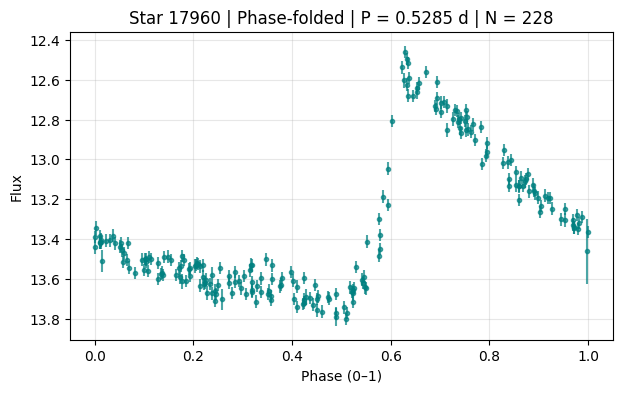

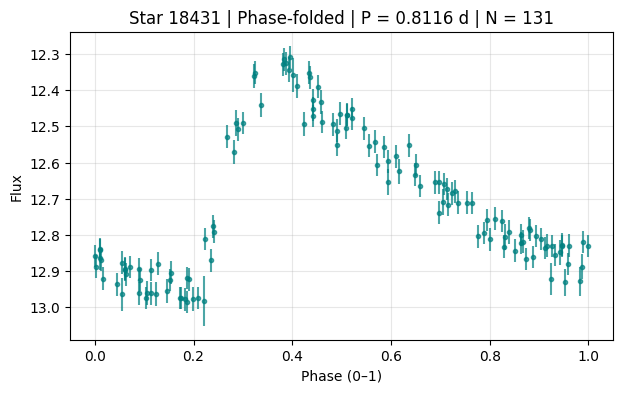

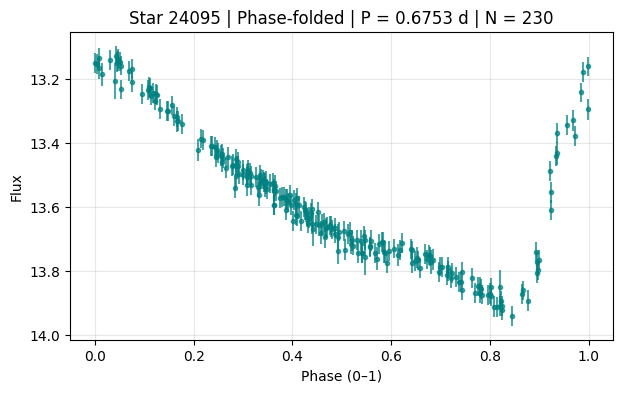

In [71]:
def fold_phase(time, period, t0=None):
    if t0 is None:
        t0 = np.min(time)
    return ((time - t0) / period) % 1.0

np.random.seed(42)
sample_ids = np.random.choice(lc_df_good["star_id"].unique(), size=3, replace=False)

for sid in sample_ids:
    g = lc_df_good[lc_df_good["star_id"] == sid]
    period = g["period"].iloc[0]
    phase = fold_phase(g["time"].values, period)

    plt.figure(figsize=(7, 4))
    plt.errorbar(phase, g["flux"], yerr=g["flux_err"], fmt=".", color="teal", alpha=0.7)
    plt.title(f"Star {sid} | Phase-folded | P = {period:.4f} d | N = {len(g)}")
    plt.xlabel("Phase (0–1)")
    plt.ylabel("Flux" if g["flux"].mean() < 100 else "Magnitude")
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3)
    plt.show()


In [72]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

def fold_phase_align(time, flux, period, align="min"):
    phase = ((time - np.min(time)) / period) % 1.0
    if align == "min":
        align_phase = phase[np.argmax(flux)]
    elif align == "max":
        align_phase = phase[np.argmin(flux)]
    else:
        align_phase = 0.0
    return (phase - align_phase) % 1.0


def normalize_mag(mag):
    mean = np.mean(mag)
    amp = np.max(mag) - np.min(mag)
    return (mag - mean) / amp

In [95]:
phase_grid = np.linspace(0, 1, 200)
templates = []

for sid, g in lc_df_good.groupby("star_id"):
    period = g["period"].iloc[0]
    phase = fold_phase_align(g["time"].values, g["flux"].values, period, align="max")
    mag_norm = normalize_mag(g["flux"].values)

    s = np.argsort(phase)
    f_interp = interp1d(phase[s], mag_norm[s], kind="cubic", fill_value="extrapolate")

    templates.append(f_interp(phase_grid))

templates = np.vstack(templates)
print(f"Interpolated {templates.shape[0]} light curves on a {len(phase_grid)}-point grid.")


Interpolated 418 light curves on a 200-point grid.


In [96]:
gamma_empirical = np.median(templates, axis=0)

In [97]:
def sigma_clip_median(data, sigma=3):
    clipped = []
    for col in data.T:
        m = np.median(col)
        s = np.std(col)
        keep = col[np.abs(col - m) < sigma * s]
        clipped.append(np.median(keep))
    return np.array(clipped)

gamma_empirical = sigma_clip_median(templates)

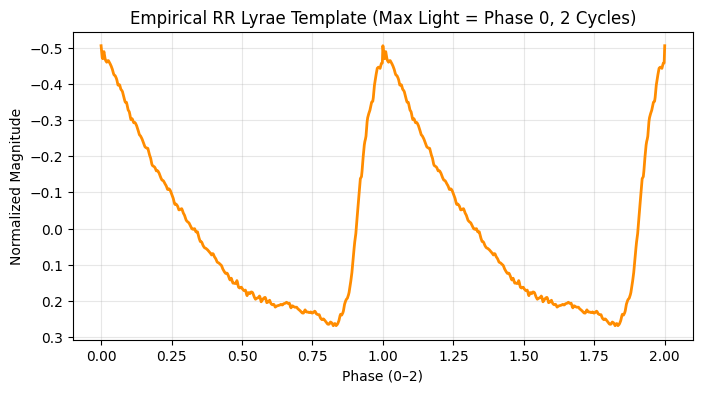

In [99]:
import numpy as np
import matplotlib.pyplot as plt

phase_of_max_light = phase_grid[np.argmin(gamma_empirical)]
phase_shifted = (phase_grid - phase_of_max_light) % 1
sort_idx = np.argsort(phase_shifted)
phase_shifted = phase_shifted[sort_idx]
gamma_shifted = gamma_empirical[sort_idx]

n_points = 500
phase_uniform = np.linspace(0, 1, n_points, endpoint=False)
gamma_uniform = np.interp(phase_uniform, phase_shifted, gamma_shifted)

phase_closed = np.append(phase_uniform, 1.0)
gamma_closed = np.append(gamma_uniform, gamma_uniform[0])
phase_double = np.concatenate([phase_closed, phase_closed + 1])
gamma_double = np.concatenate([gamma_closed, gamma_closed])

plt.figure(figsize=(8, 4))
plt.plot(phase_double, gamma_double, color="darkorange", lw=2)
plt.title("Empirical RR Lyrae Template (Max Light = Phase 0, 2 Cycles)")
plt.xlabel("Phase (0–2)")
plt.ylabel("Normalized Magnitude")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.savefig("rr_lyrae_template_ab.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#taking more high quality stars and compare if you have less quality and high quality, how your template changes
#will create some distortion in the template, will produce more and more in the quality cuts and compare, that would be good to see how
    # the template changes